# Baseline EKF Analysis
**Raw sensor data + unfiltered dual-EKF (no QNN pre-filter)**

Topics consumed (from `record_baseline_bag.sh`):
- `/imu/data` — raw IMU
- `/gps/fix` — raw GPS
- `/diff_drive_controller/odom` — raw wheel odometry
- `/odometry/visual` — RTAB-Map visual odometry
- `/odometry/lidar` — RTAB-Map LiDAR odometry
- `/odometry/local` — EKF #1 output (odom frame)
- `/odometry/global` — EKF #2 output (map frame, GPS-corrected)
- `/cmd_vel` — commanded velocity

**Record with:**
```bash
source /home/anish/Multi-sensor-fusion/install/setup.bash
bash /home/anish/Multi-sensor-fusion/record_baseline_bag.sh
```

In [12]:
# ── SET BAG PATH ──────────────────────────────────────────────────────────────
BAG_PATH = '/home/rosdata/rosbags/moving_bot_baseline_test_20260420_222201'
PLOT_DIR = '/home/anish/Multi-sensor-fusion/plots/baseline'
# ─────────────────────────────────────────────────────────────────────────────

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy import stats
from scipy.signal import welch, savgol_filter
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

os.makedirs(PLOT_DIR, exist_ok=True)
typestore = get_typestore(Stores.ROS2_HUMBLE)

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a', 'grid.alpha': 0.5,
    'legend.facecolor': '#16213e', 'legend.edgecolor': '#444444',
    'font.size': 11, 'figure.dpi': 100,
})

C = {
    'raw_odom':   '#ff6b6b',
    'visual':     '#a29bfe',
    'lidar':      '#74b9ff',
    'ekf_local':  '#51cf66',
    'ekf_global': '#339af0',
    'gps':        '#ffd43b',
    'imu':        '#20c997',
    'cmd_vel':    '#cc5de8',
}

def quat_to_yaw(q):
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)

def npc(df, col):
    return pd.to_numeric(df[col], errors='coerce').to_numpy()

def mask_finite(*arrs):
    m = np.ones(len(arrs[0]), dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m

print(f'Bag: {BAG_PATH}')
print(f'Exists: {Path(BAG_PATH).exists()}')

Bag: /home/rosdata/rosbags/moving_bot_baseline_test_20260420_222201
Exists: True


## 1. Extract Data from Bag

In [13]:
raw = {
    'wheel': [], 'visual': [], 'lidar': [],
    'ekf_local': [], 'ekf_global': [],
    'gps': [], 'imu': [], 'cmd_vel': []
}

TOPIC_MAP = {
    '/diff_drive_controller/odom': 'wheel',
    '/odometry/visual':            'visual',
    '/odometry/lidar':             'lidar',
    '/odometry/local':             'ekf_local',
    '/odometry/global':            'ekf_global',
    '/gps/fix':                    'gps',
    '/imu/data':                   'imu',
    '/cmd_vel':                    'cmd_vel',
}

with AnyReader([Path(BAG_PATH)], default_typestore=typestore) as reader:
    available = list(reader.topics.keys())
    print('Topics in bag:', available)
    for connection, timestamp, rawdata in reader.messages():
        key = TOPIC_MAP.get(connection.topic)
        if key is None:
            continue
        msg = reader.deserialize(rawdata, connection.msgtype)
        t = timestamp * 1e-9

        if key in ('wheel', 'visual', 'lidar', 'ekf_local', 'ekf_global'):
            raw[key].append({
                't': t,
                'x': msg.pose.pose.position.x,
                'y': msg.pose.pose.position.y,
                'yaw': quat_to_yaw(msg.pose.pose.orientation),
                'vx': msg.twist.twist.linear.x,
                'wz': msg.twist.twist.angular.z,
                'cov_xx': msg.pose.covariance[0],
                'cov_yy': msg.pose.covariance[7],
                'cov_yaw': msg.pose.covariance[35],
            })
        elif key == 'gps':
            raw[key].append({
                't': t,
                'lat': msg.latitude, 'lon': msg.longitude,
                'cov': msg.position_covariance[0],
            })
        elif key == 'imu':
            raw[key].append({
                't': t,
                'ax': msg.linear_acceleration.x,
                'ay': msg.linear_acceleration.y,
                'az': msg.linear_acceleration.z,
                'gx': msg.angular_velocity.x,
                'gy': msg.angular_velocity.y,
                'gz': msg.angular_velocity.z,
                'yaw': quat_to_yaw(msg.orientation),
            })
        elif key == 'cmd_vel':
            raw[key].append({
                't': t,
                'vx': msg.linear.x,
                'wz': msg.angular.z,
            })

# Convert to DataFrames, normalize t=0
dfs = {}
t0 = min(raw[k][0]['t'] for k in raw if raw[k])
for k, rows in raw.items():
    if rows:
        df = pd.DataFrame(rows)
        df['t'] -= t0
        dfs[k] = df

# Summary
print(f'\n{"Source":>12}  {"Msgs":>6}  {"Duration":>9}  {"Rate":>8}')
print('─' * 45)
for k, df in dfs.items():
    dur = df['t'].iloc[-1] - df['t'].iloc[0] if len(df) > 1 else 0
    hz = len(df) / dur if dur > 0 else 0
    print(f'{k:>12}  {len(df):6d}  {dur:8.1f}s  {hz:7.1f} Hz')

Topics in bag: ['/clock', '/cmd_vel', '/diff_drive_controller/odom', '/gps/fix', '/imu/data', '/joint_states', '/odometry/global', '/odometry/lidar', '/odometry/local', '/odometry/visual', '/tf', '/tf_static']

      Source    Msgs   Duration      Rate
─────────────────────────────────────────────
       wheel    2656     120.0s     22.1 Hz
      visual    1020     126.8s      8.0 Hz
       lidar     284     126.4s      2.2 Hz
   ekf_local    2844     127.0s     22.4 Hz
  ekf_global    2844     127.0s     22.4 Hz
         gps     569     126.8s      4.5 Hz
         imu   11374     127.0s     89.6 Hz
     cmd_vel    2395     124.2s     19.3 Hz


## 2. XY Trajectory — All Sources

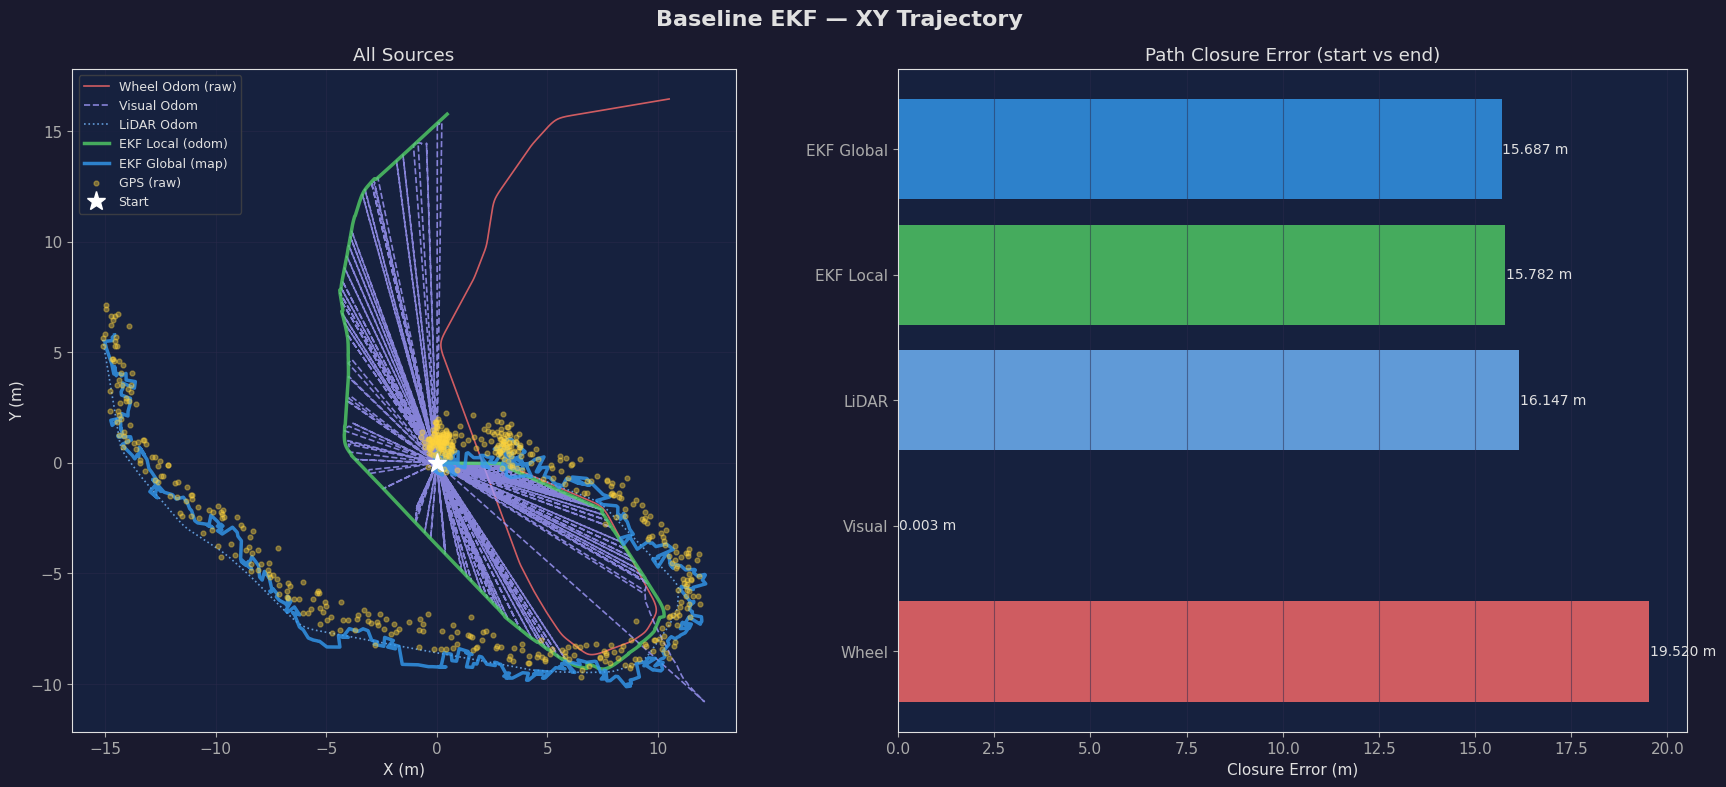

Saved: 01_trajectory.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Baseline EKF — XY Trajectory', fontsize=16, fontweight='bold')

# Left: all raw sources + EKF
ax = axes[0]
ax.set_title('All Sources')
for k, label, color, lw, ls in [
    ('wheel',      'Wheel Odom (raw)',   C['raw_odom'],  1.2, '-'),
    ('visual',     'Visual Odom',        C['visual'],    1.2, '--'),
    ('lidar',      'LiDAR Odom',         C['lidar'],     1.2, ':'),
    ('ekf_local',  'EKF Local (odom)',   C['ekf_local'], 2.5, '-'),
    ('ekf_global', 'EKF Global (map)',   C['ekf_global'],2.5, '-'),
]:
    if k in dfs:
        x, y = npc(dfs[k], 'x'), npc(dfs[k], 'y')
        m = mask_finite(x, y)
        ax.plot(x[m], y[m], color=color, lw=lw, ls=ls, label=label, alpha=0.8)

# GPS scatter
if 'gps' in dfs:
    g = dfs['gps']
    lat_m = (npc(g, 'lat') - npc(g, 'lat').mean()) * 111320
    lon_m = (npc(g, 'lon') - npc(g, 'lon').mean()) * 111320 * np.cos(np.radians(npc(g, 'lat').mean()))
    # align GPS origin to EKF global start
    if 'ekf_global' in dfs:
        lat_m += dfs['ekf_global']['x'].iloc[0] - lat_m[0]
        lon_m += dfs['ekf_global']['y'].iloc[0] - lon_m[0]
    ax.scatter(lon_m, lat_m, c=C['gps'], s=12, alpha=0.4, zorder=5, label='GPS (raw)')

ax.plot(0, 0, 'w*', ms=14, zorder=10, label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True)

# Right: closure error bars
ax2 = axes[1]
ax2.set_title('Path Closure Error (start vs end)')
names, errors = [], []
for k, label in [('wheel','Wheel'), ('visual','Visual'), ('lidar','LiDAR'),
                  ('ekf_local','EKF Local'), ('ekf_global','EKF Global')]:
    if k in dfs:
        x, y = npc(dfs[k], 'x'), npc(dfs[k], 'y')
        m = mask_finite(x, y)
        if m.sum() > 1:
            err = np.sqrt((x[m][-1] - x[m][0])**2 + (y[m][-1] - y[m][0])**2)
            names.append(label)
            errors.append(err)

bar_colors = [C['raw_odom'], C['visual'], C['lidar'], C['ekf_local'], C['ekf_global']]
bars = ax2.barh(names, errors, color=bar_colors[:len(names)], alpha=0.8)
for bar, err in zip(bars, errors):
    ax2.text(err + 0.02, bar.get_y() + bar.get_height()/2,
             f'{err:.3f} m', va='center', fontsize=10)
ax2.set_xlabel('Closure Error (m)')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/01_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_trajectory.png')

## 3. Velocity Analysis — cmd_vel vs Raw vs EKF

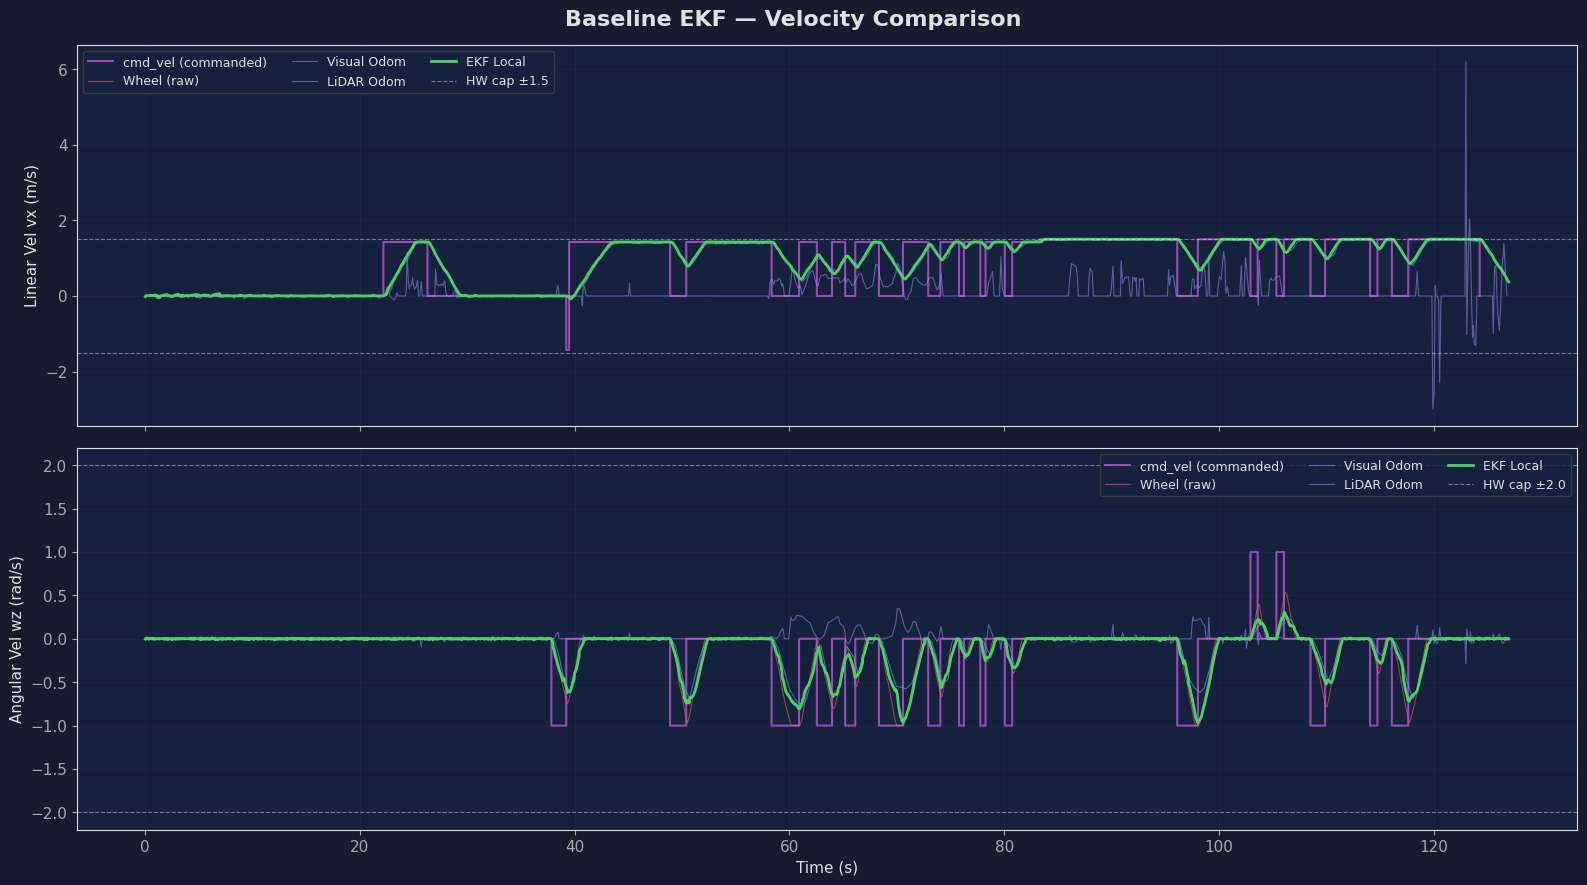


Velocity RMS error vs cmd_vel (tracking accuracy):
  Wheel       : vx RMSE = 0.5103 m/s
  EKF Local   : vx RMSE = 0.5210 m/s


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Baseline EKF — Velocity Comparison', fontsize=16, fontweight='bold')

for key, (vel_col, ax, ylabel, hw_cap) in [
    ('vx',  ('vx',  axes[0], 'Linear Vel vx (m/s)',    1.5)),
    ('wz',  ('wz',  axes[1], 'Angular Vel wz (rad/s)', 2.0)),
]:
    col, ax, ylabel, cap = vel_col, ax, ylabel, hw_cap
    if 'cmd_vel' in dfs:
        t, v = npc(dfs['cmd_vel'], 't'), npc(dfs['cmd_vel'], col)
        m = mask_finite(t, v)
        ax.step(t[m], v[m], color=C['cmd_vel'], lw=1.5, alpha=0.7, where='post', label='cmd_vel (commanded)')
    for k, label, color in [
        ('wheel',      'Wheel (raw)',       C['raw_odom']),
        ('visual',     'Visual Odom',       C['visual']),
        ('lidar',      'LiDAR Odom',        C['lidar']),
        ('ekf_local',  'EKF Local',         C['ekf_local']),
    ]:
        if k in dfs:
            t, v = npc(dfs[k], 't'), npc(dfs[k], col)
            m = mask_finite(t, v)
            lw = 2.0 if 'ekf' in k else 0.8
            alpha = 1.0 if 'ekf' in k else 0.5
            ax.plot(t[m], v[m], color=color, lw=lw, alpha=alpha, label=label)
    ax.axhline(cap, color='white', ls='--', lw=0.8, alpha=0.4, label=f'HW cap ±{cap}')
    ax.axhline(-cap, color='white', ls='--', lw=0.8, alpha=0.4)
    ax.set_ylabel(ylabel); ax.legend(fontsize=9, ncol=3); ax.grid(True)

axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_velocity.png', dpi=150, bbox_inches='tight')
plt.show()

# Velocity noise stats
print('\nVelocity RMS error vs cmd_vel (tracking accuracy):')
if 'cmd_vel' in dfs:
    tc = npc(dfs['cmd_vel'], 't')
    vc = npc(dfs['cmd_vel'], 'vx')
    mc = mask_finite(tc, vc)
    for k, label in [('wheel','Wheel'), ('ekf_local','EKF Local')]:
        if k in dfs:
            tv, vv = npc(dfs[k], 't'), npc(dfs[k], 'vx')
            mv = mask_finite(tv, vv)
            v_interp = np.interp(tc[mc], tv[mv], vv[mv])
            rmse = np.sqrt(np.mean((vc[mc] - v_interp)**2))
            print(f'  {label:12}: vx RMSE = {rmse:.4f} m/s')

## 4. Heading/Yaw — Raw Odom vs IMU vs EKF Fused

Final yaw drift (wheel vs EKF): -32.85°
Max yaw drift: 34.97°


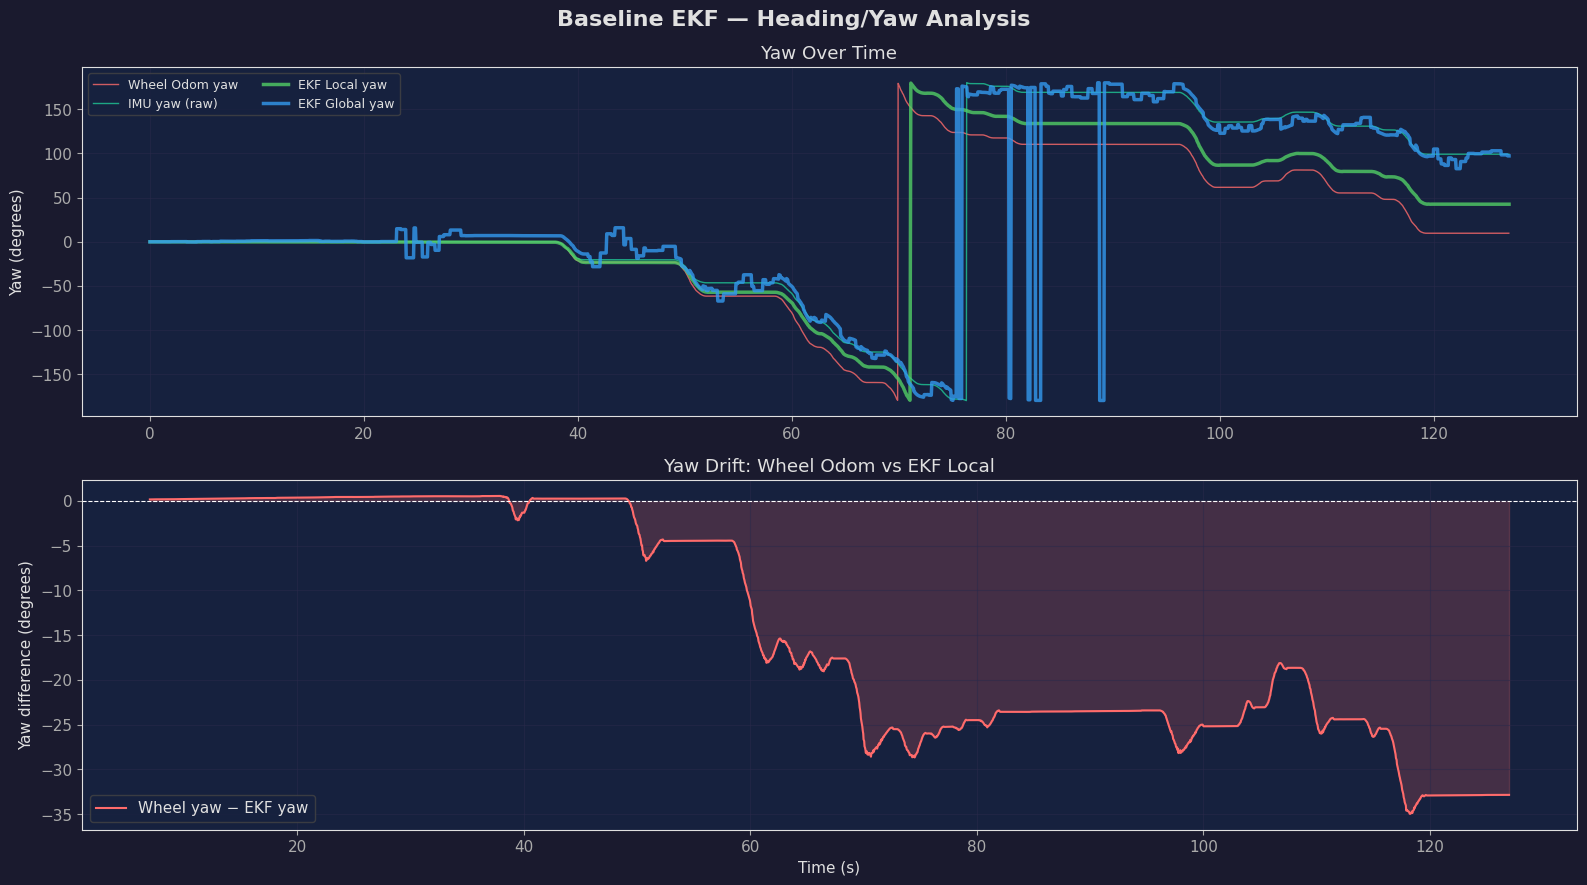

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Baseline EKF — Heading/Yaw Analysis', fontsize=16, fontweight='bold')

# Top: yaw timeseries
ax = axes[0]
for k, label, color, lw in [
    ('wheel',      'Wheel Odom yaw',   C['raw_odom'],  1.0),
    ('imu',        'IMU yaw (raw)',     C['imu'],       1.0),
    ('ekf_local',  'EKF Local yaw',    C['ekf_local'], 2.5),
    ('ekf_global', 'EKF Global yaw',   C['ekf_global'],2.5),
]:
    if k in dfs:
        t = npc(dfs[k], 't')
        yaw_deg = np.degrees(npc(dfs[k], 'yaw'))
        m = mask_finite(t, yaw_deg)
        ax.plot(t[m], yaw_deg[m], color=color, lw=lw, label=label, alpha=0.8)
ax.set_ylabel('Yaw (degrees)'); ax.legend(fontsize=9, ncol=2); ax.grid(True)
ax.set_title('Yaw Over Time')

# Bottom: yaw drift = wheel_odom_yaw - ekf_local_yaw
ax2 = axes[1]
if 'wheel' in dfs and 'ekf_local' in dfs:
    tw = npc(dfs['wheel'], 't')
    yw = npc(dfs['wheel'], 'yaw')
    mw = mask_finite(tw, yw)
    te = npc(dfs['ekf_local'], 't')
    ye = npc(dfs['ekf_local'], 'yaw')
    me = mask_finite(te, ye)
    ye_interp = np.interp(tw[mw], te[me], ye[me])
    drift_deg = np.degrees(tw[mw] * 0)  # placeholder
    # unwrap both then diff
    yw_unwrap = np.unwrap(yw[mw])
    ye_unwrap = np.interp(tw[mw], te[me], np.unwrap(ye[me]))
    yaw_diff = np.degrees(yw_unwrap - ye_unwrap)
    ax2.plot(tw[mw], yaw_diff, color=C['raw_odom'], lw=1.5, label='Wheel yaw − EKF yaw')
    ax2.fill_between(tw[mw], 0, yaw_diff, alpha=0.2, color=C['raw_odom'])
    ax2.axhline(0, color='white', ls='--', lw=0.8)
    ax2.set_title('Yaw Drift: Wheel Odom vs EKF Local')
    ax2.set_ylabel('Yaw difference (degrees)')
    print(f'Final yaw drift (wheel vs EKF): {yaw_diff[-1]:.2f}°')
    print(f'Max yaw drift: {np.abs(yaw_diff).max():.2f}°')

ax2.set_xlabel('Time (s)'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_yaw.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. IMU Raw Noise Analysis

IMU rate: 89.6 Hz,  samples: 11374


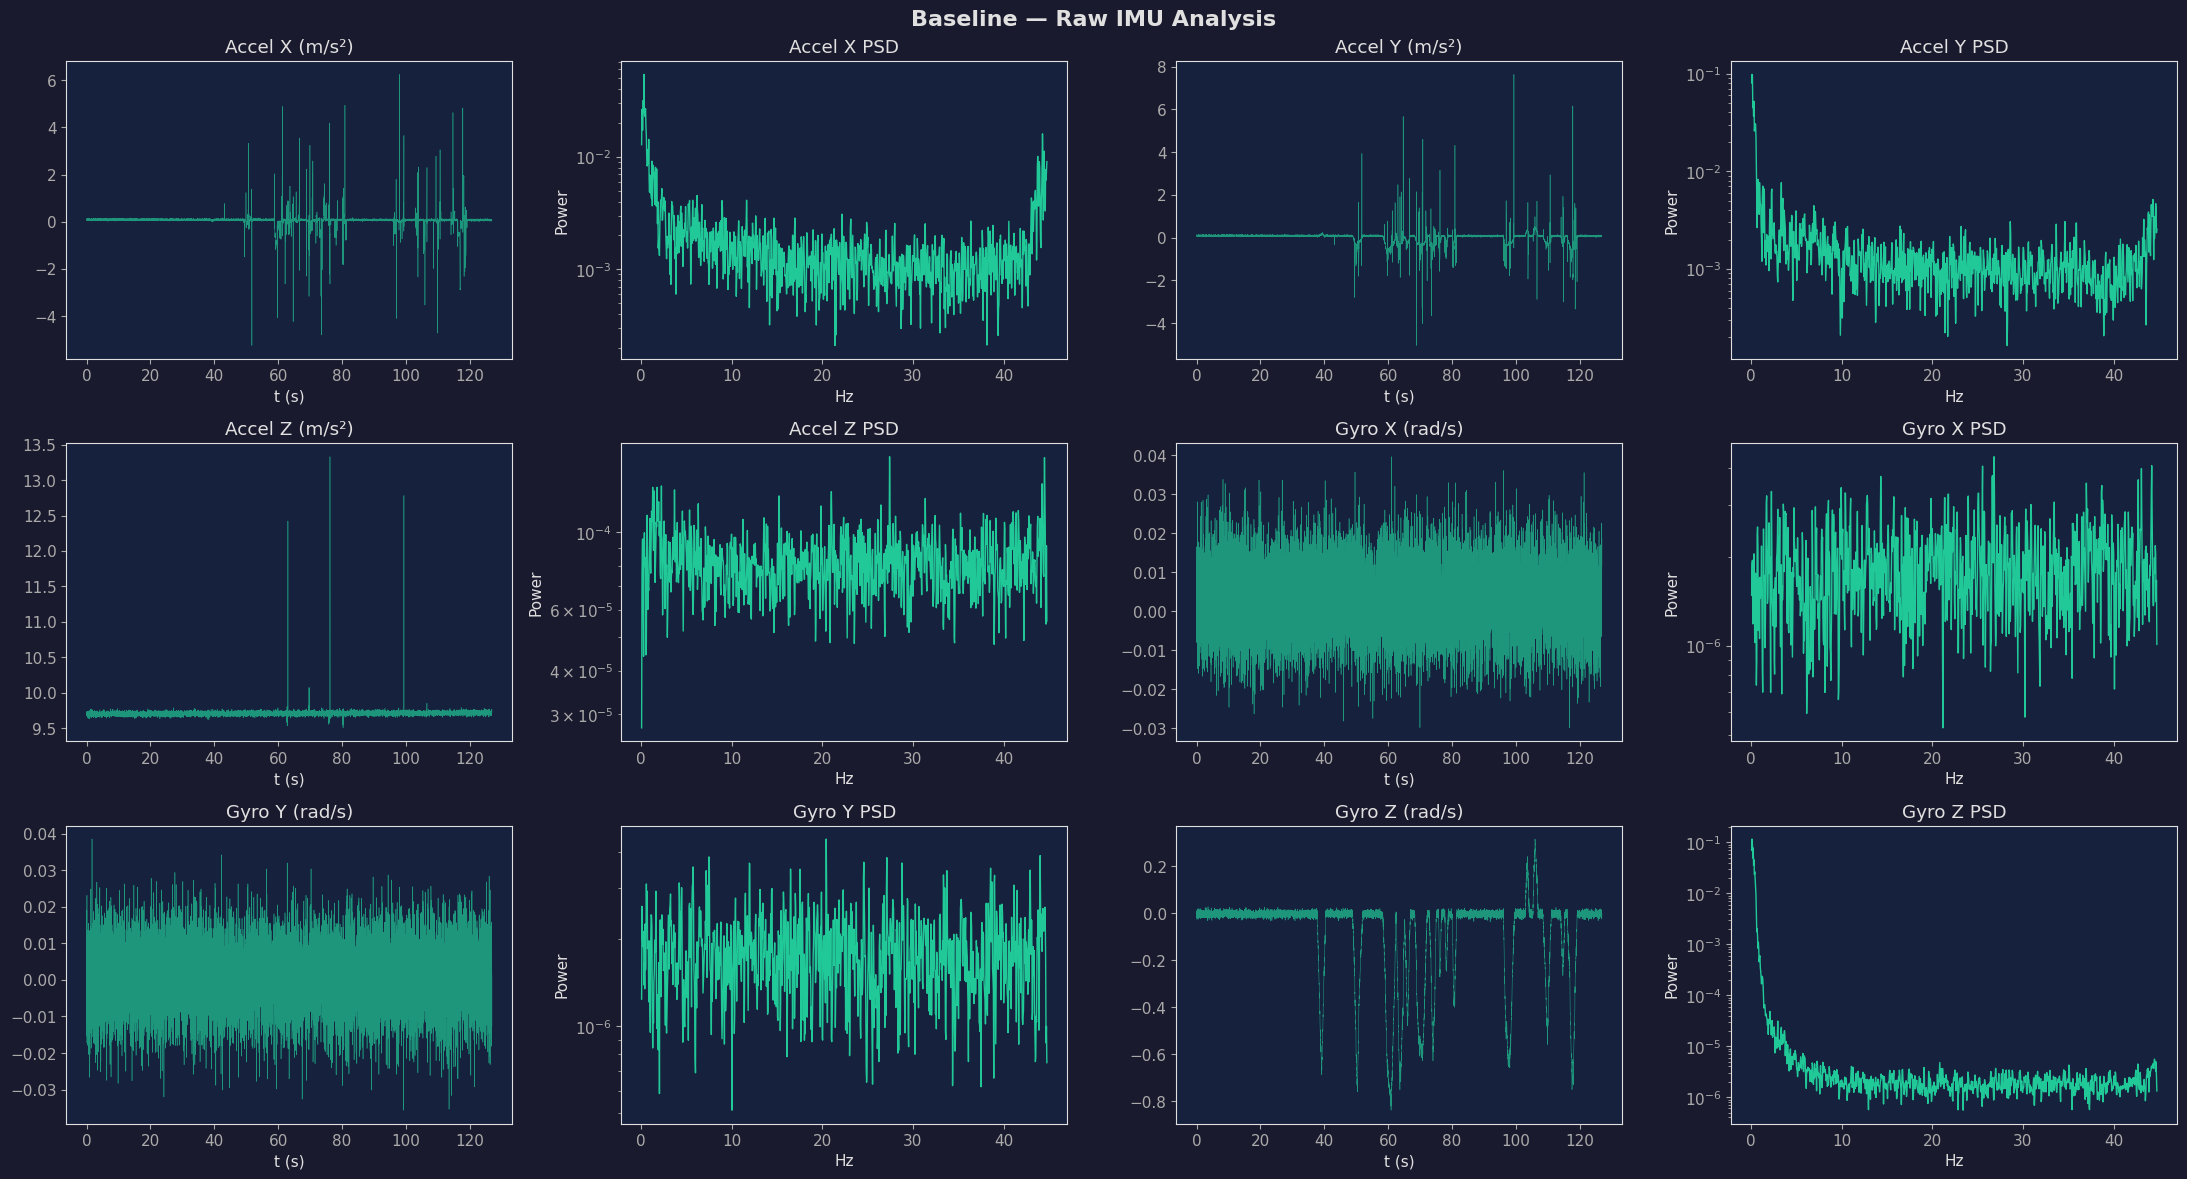


Raw IMU noise statistics:
   Channel        Mean         Std         Min         Max
────────────────────────────────────────────────────────
   Accel X     0.06470     0.29773    -5.24267     6.24882
   Accel Y     0.01064     0.30522    -5.03962     7.63433
   Accel Z     9.71040     0.05625     9.50603    13.32883
    Gyro X     0.00318     0.00902    -0.02995     0.03966
    Gyro Y     0.00059     0.00894    -0.03562     0.03852
    Gyro Z    -0.08331     0.18404    -0.83847     0.31583


In [17]:
if 'imu' not in dfs:
    print('No IMU data'); 
else:
    imu = dfs['imu']
    fs_imu = 1.0 / np.mean(np.diff(npc(imu, 't')))
    print(f'IMU rate: {fs_imu:.1f} Hz,  samples: {len(imu)}')

    fig, axes = plt.subplots(3, 4, figsize=(22, 12))
    fig.suptitle('Baseline — Raw IMU Analysis', fontsize=16, fontweight='bold')

    channels = [
        ('ax','Accel X','m/s²'), ('ay','Accel Y','m/s²'), ('az','Accel Z','m/s²'),
        ('gx','Gyro X','rad/s'), ('gy','Gyro Y','rad/s'), ('gz','Gyro Z','rad/s'),
    ]
    for i, (col, label, unit) in enumerate(channels):
        row, col_i = i // 2, (i % 2) * 2
        d = npc(imu, col)
        t = npc(imu, 't')
        m = mask_finite(t, d)

        # Timeseries
        axes[row, col_i].plot(t[m], d[m], color=C['imu'], lw=0.4, alpha=0.7)
        axes[row, col_i].set_title(f'{label} ({unit})')
        axes[row, col_i].set_xlabel('t (s)')

        # PSD
        d_z = d[m] - np.mean(d[m])
        nperseg = min(2048, len(d_z) // 4)
        f_psd, Pxx = welch(d_z, fs=fs_imu, nperseg=nperseg)
        axes[row, col_i+1].semilogy(f_psd[1:], Pxx[1:], color=C['imu'], lw=1)
        axes[row, col_i+1].set_title(f'{label} PSD')
        axes[row, col_i+1].set_xlabel('Hz')
        axes[row, col_i+1].set_ylabel('Power')

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/04_imu_noise.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nRaw IMU noise statistics:')
    print(f'{"Channel":>10}  {"Mean":>10}  {"Std":>10}  {"Min":>10}  {"Max":>10}')
    print('─' * 56)
    for col, label, unit in channels:
        d = npc(imu, col)
        d = d[np.isfinite(d)]
        print(f'{label:>10}  {d.mean():10.5f}  {d.std():10.5f}  {d.min():10.5f}  {d.max():10.5f}')

## 6. Visual vs LiDAR Odometry Trust Analysis
Noise level, consistency, and how much each contributes to EKF drift.

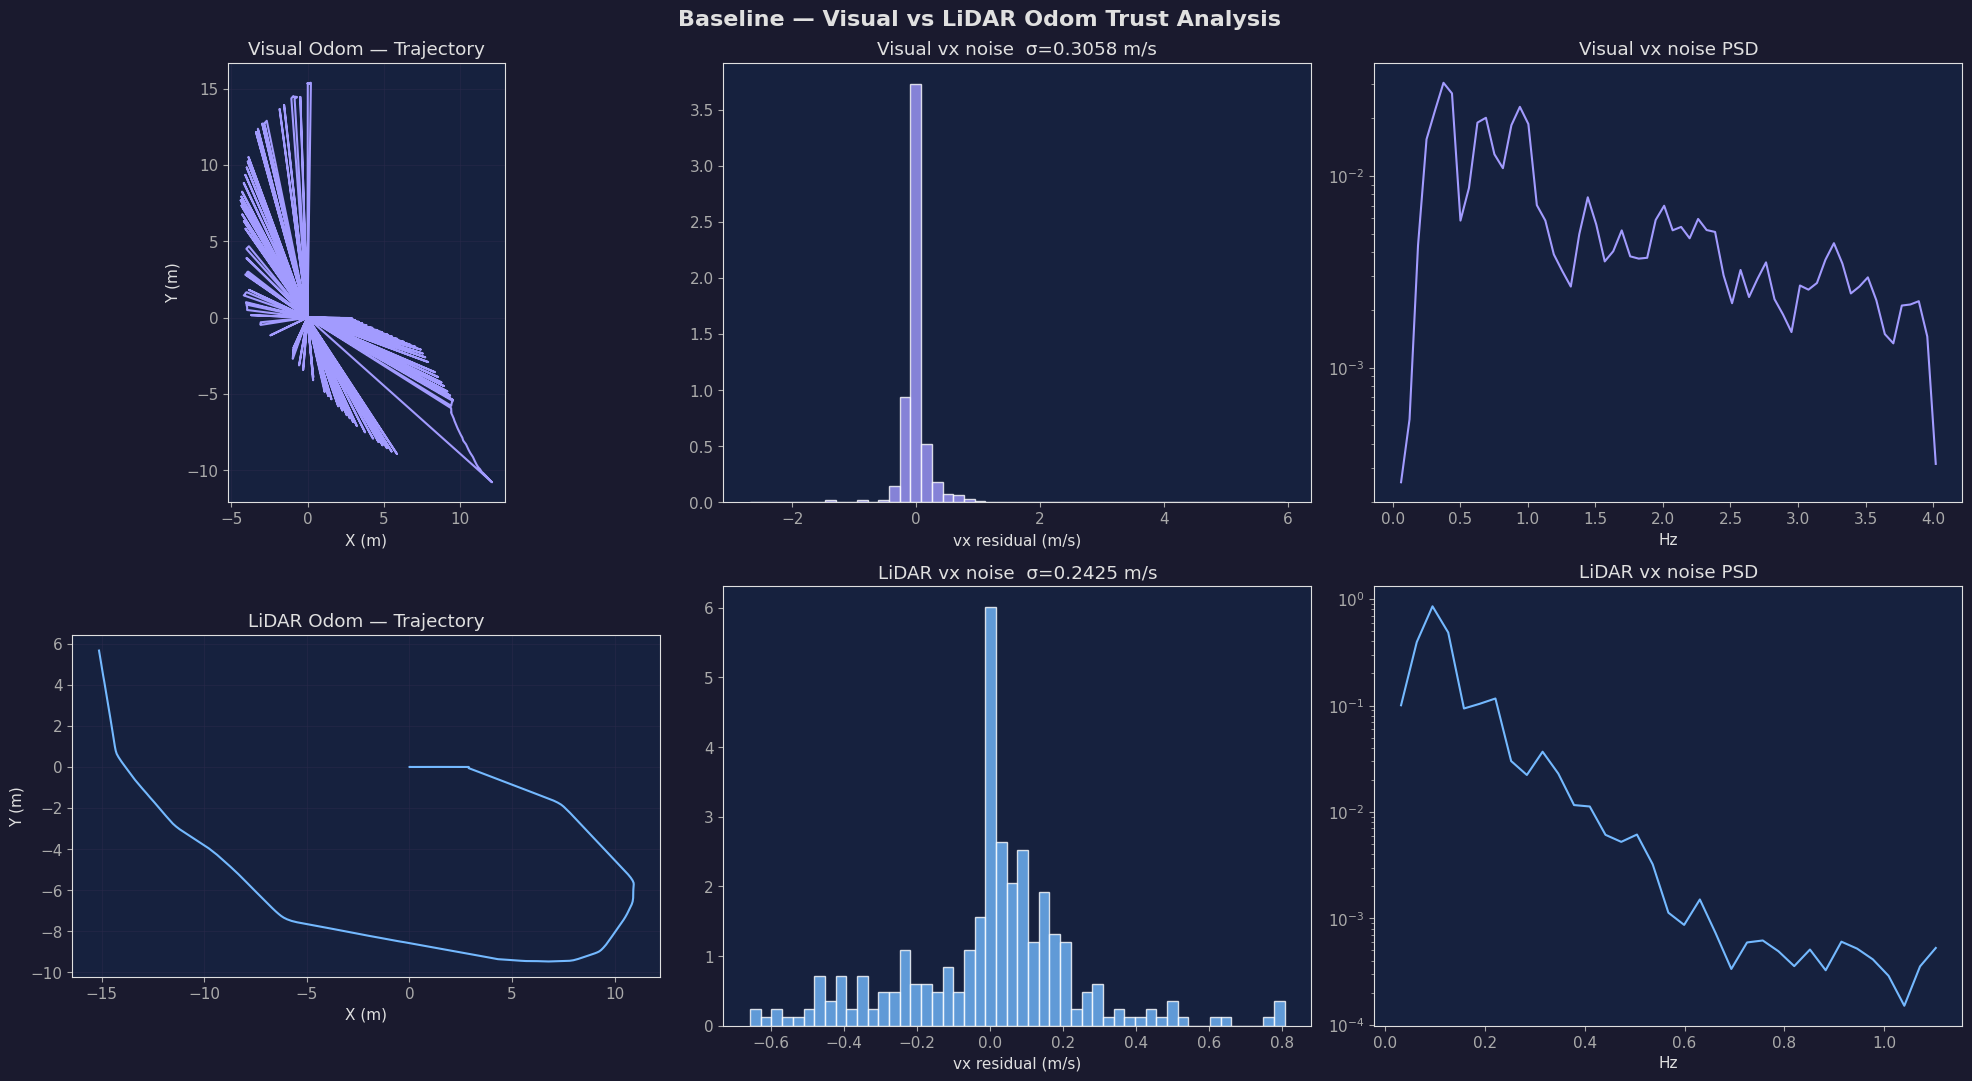


Odometry noise summary (detrended):
    Source       vx σ       wz σ     Rate    Closure
───────────────────────────────────────────────────────
     Wheel    0.02123    0.02981     22.1    19.5202 m
    Visual    0.30580    0.03723      8.0     0.0029 m
     LiDAR    0.24249    0.16040      2.2    16.1474 m


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Baseline — Visual vs LiDAR Odom Trust Analysis', fontsize=16, fontweight='bold')

for i, (k, name, color) in enumerate([('visual', 'Visual', C['visual']),
                                        ('lidar',  'LiDAR',  C['lidar'])]):
    if k not in dfs:
        continue
    df = dfs[k]
    t   = npc(df, 't')
    vx  = npc(df, 'vx')
    wz  = npc(df, 'wz')
    x   = npc(df, 'x')
    y   = npc(df, 'y')

    # Detrended vx noise
    wl = min(51, max(5, (len(df)//5)*2+1))
    if wl % 2 == 0: wl += 1
    m = mask_finite(t, vx)
    trend_vx = savgol_filter(vx[m], wl, 3)
    noise_vx = vx[m] - trend_vx

    # Trajectory
    mx = mask_finite(x, y)
    axes[i, 0].plot(x[mx], y[mx], color=color, lw=1.5)
    axes[i, 0].set_title(f'{name} Odom — Trajectory')
    axes[i, 0].set_aspect('equal'); axes[i, 0].grid(True)
    axes[i, 0].set_xlabel('X (m)'); axes[i, 0].set_ylabel('Y (m)')

    # vx noise histogram
    axes[i, 1].hist(noise_vx, bins=50, density=True, color=color, alpha=0.8, edgecolor='white')
    axes[i, 1].set_title(f'{name} vx noise  σ={noise_vx.std():.4f} m/s')
    axes[i, 1].set_xlabel('vx residual (m/s)')

    # vx PSD
    fs_k = 1.0 / np.mean(np.diff(t[m]))
    f_psd, Pxx = welch(noise_vx, fs=fs_k, nperseg=min(128, len(noise_vx)//4))
    axes[i, 2].semilogy(f_psd[1:], Pxx[1:], color=color, lw=1.5)
    axes[i, 2].set_title(f'{name} vx noise PSD')
    axes[i, 2].set_xlabel('Hz')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_vo_lo_trust.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOdometry noise summary (detrended):')
print(f'{"Source":>10}  {"vx σ":>9}  {"wz σ":>9}  {"Rate":>7}  {"Closure":>9}')
print('─' * 55)
for k, name in [('wheel','Wheel'), ('visual','Visual'), ('lidar','LiDAR')]:
    if k not in dfs: continue
    df = dfs[k]
    t  = npc(df, 't'); vx = npc(df, 'vx'); wz = npc(df, 'wz')
    x  = npc(df, 'x'); y  = npc(df, 'y')
    m  = mask_finite(t, vx)
    wl = min(51, max(5, (m.sum()//5)*2+1))
    if wl % 2 == 0: wl += 1
    std_vx = np.std(vx[m] - savgol_filter(vx[m], wl, 3))
    std_wz = np.std(wz[m] - savgol_filter(wz[m], wl, 3))
    mx = mask_finite(x, y)
    closure = np.sqrt((x[mx][-1]-x[mx][0])**2 + (y[mx][-1]-y[mx][0])**2) if mx.sum()>1 else 0
    hz = len(df) / (t[-1] - t[0]) if len(df) > 1 else 0
    print(f'{name:>10}  {std_vx:9.5f}  {std_wz:9.5f}  {hz:7.1f}  {closure:9.4f} m')

## 7. Drift Analysis — EKF Local vs Global Divergence

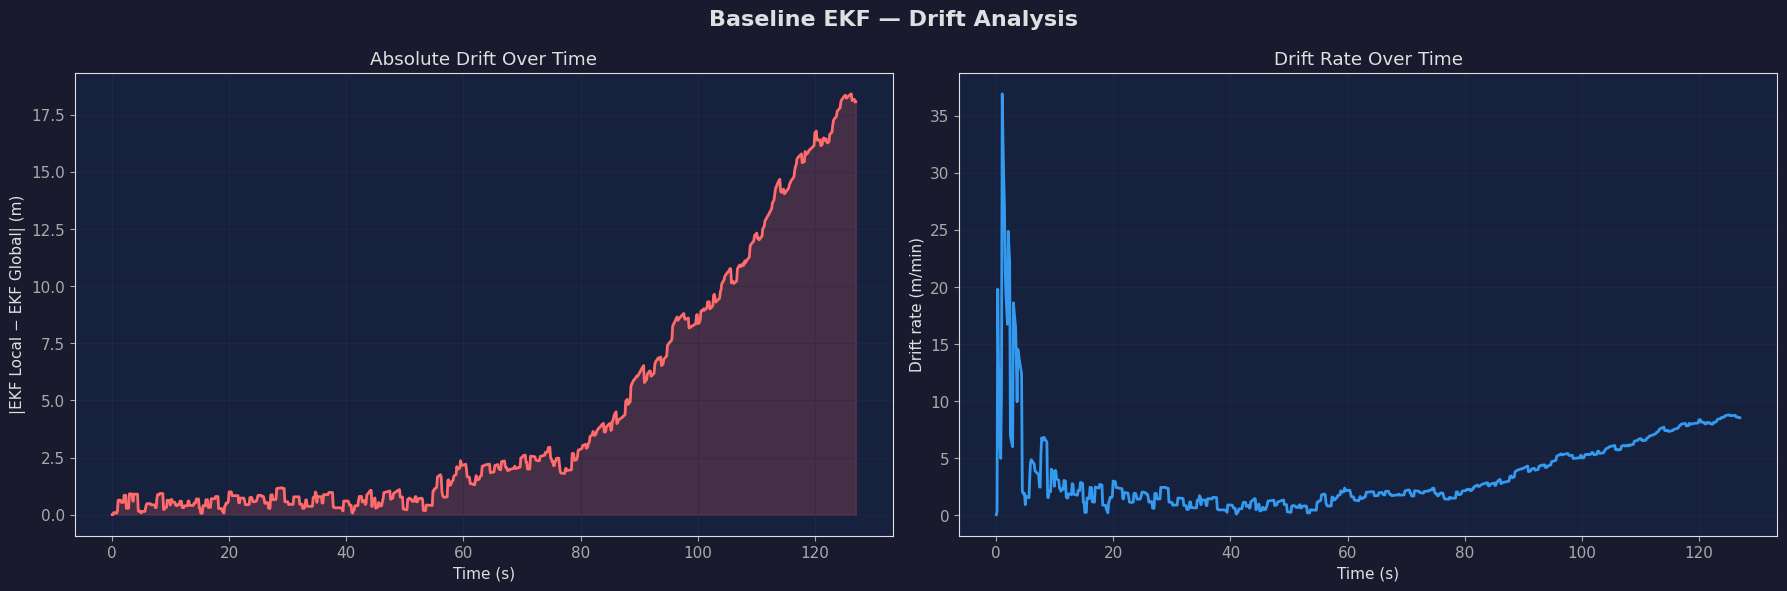


Drift Summary (Baseline EKF):
  Duration         : 127.0 s
  Final drift      : 18.0701 m
  Max drift        : 18.4139 m
  Mean drift rate  : 8.5380 m/min
  Drift @ 60s      : 2.1713 m  (if bag long enough)


In [19]:
if 'ekf_local' not in dfs or 'ekf_global' not in dfs:
    print('Need both /odometry/local and /odometry/global')
else:
    local = dfs['ekf_local']
    glob_ = dfs['ekf_global']

    tl = npc(local, 't'); xl = npc(local, 'x'); yl = npc(local, 'y')
    tg = npc(glob_, 't'); xg = npc(glob_, 'x'); yg = npc(glob_, 'y')
    ml = mask_finite(tl, xl, yl); mg = mask_finite(tg, xg, yg)

    t_common = np.linspace(max(tl[ml][0], tg[mg][0]), min(tl[ml][-1], tg[mg][-1]), 1000)
    lx_i = np.interp(t_common, tl[ml], xl[ml] - xl[ml][0])
    ly_i = np.interp(t_common, tl[ml], yl[ml] - yl[ml][0])
    gx_i = np.interp(t_common, tg[mg], xg[mg] - xg[mg][0])
    gy_i = np.interp(t_common, tg[mg], yg[mg] - yg[mg][0])
    drift = np.sqrt((lx_i - gx_i)**2 + (ly_i - gy_i)**2)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Baseline EKF — Drift Analysis', fontsize=16, fontweight='bold')

    axes[0].plot(t_common, drift, color=C['raw_odom'], lw=2)
    axes[0].fill_between(t_common, 0, drift, color=C['raw_odom'], alpha=0.2)
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('|EKF Local − EKF Global| (m)')
    axes[0].set_title('Absolute Drift Over Time')
    axes[0].grid(True)

    # Drift rate (cumulative / time)
    drift_rate = drift / (t_common + 1e-6) * 60  # m/min
    axes[1].plot(t_common, drift_rate, color=C['ekf_global'], lw=2)
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Drift rate (m/min)')
    axes[1].set_title('Drift Rate Over Time')
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/06_drift.png', dpi=150, bbox_inches='tight')
    plt.show()

    dur = t_common[-1] - t_common[0]
    print(f'\nDrift Summary (Baseline EKF):')
    print(f'  Duration         : {dur:.1f} s')
    print(f'  Final drift      : {drift[-1]:.4f} m')
    print(f'  Max drift        : {drift.max():.4f} m')
    print(f'  Mean drift rate  : {drift[-1]/dur*60:.4f} m/min')
    print(f'  Drift @ 60s      : {np.interp(60.0, t_common, drift):.4f} m  (if bag long enough)')

## 8. GPS Innovation Analysis
Innovation = GPS position − EKF global estimate. Well-tuned EKF → zero-mean Gaussian.

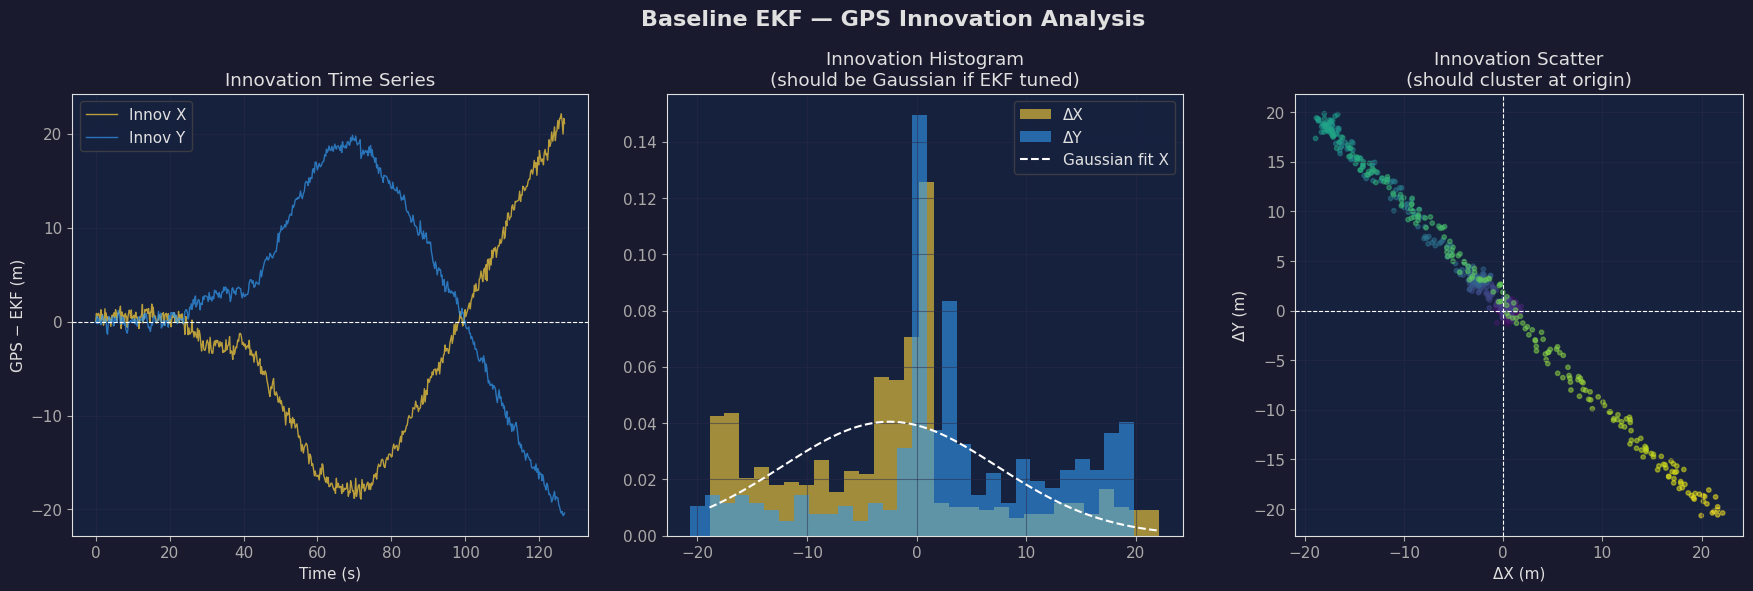


GPS Innovation Statistics (Baseline EKF):
  ΔX  mean=-2.4569 m   std=9.8407 m
  ΔY  mean=3.1229 m   std=9.8981 m
  2D RMSE = 14.5121 m
  Normality (X): p=0.0014 (>0.05 = Gaussian)
  Normality (Y): p=0.0028


In [20]:
if 'gps' not in dfs or 'ekf_global' not in dfs:
    print('Need /gps/fix and /odometry/global')
else:
    gps = dfs['gps']
    ekf = dfs['ekf_global']

    # Convert GPS lat/lon to local meters (ENU-aligned)
    lat = npc(gps, 'lat'); lon = npc(gps, 'lon')
    lat_m = (lat - lat[0]) * 111320
    lon_m = (lon - lon[0]) * 111320 * np.cos(np.radians(lat[0]))

    tg = npc(gps, 't'); te = npc(ekf, 't')
    xe = npc(ekf, 'x'); ye = npc(ekf, 'y')
    me = mask_finite(te, xe, ye)

    # Align GPS to EKF origin
    lat_m += xe[me][0] - lat_m[0]
    lon_m += ye[me][0] - lon_m[0]

    mg = mask_finite(tg, lat_m, lon_m)
    ekf_x_interp = np.interp(tg[mg], te[me], xe[me])
    ekf_y_interp = np.interp(tg[mg], te[me], ye[me])

    innov_x = lat_m[mg] - ekf_x_interp
    innov_y = lon_m[mg] - ekf_y_interp

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Baseline EKF — GPS Innovation Analysis', fontsize=16, fontweight='bold')

    axes[0].plot(tg[mg], innov_x, color=C['gps'], alpha=0.7, lw=1, label='Innov X')
    axes[0].plot(tg[mg], innov_y, color=C['ekf_global'], alpha=0.7, lw=1, label='Innov Y')
    axes[0].axhline(0, color='white', ls='--', lw=0.8)
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('GPS − EKF (m)')
    axes[0].set_title('Innovation Time Series'); axes[0].legend(); axes[0].grid(True)

    axes[1].hist(innov_x, bins=30, color=C['gps'], alpha=0.6, density=True, label='ΔX')
    axes[1].hist(innov_y, bins=30, color=C['ekf_global'], alpha=0.6, density=True, label='ΔY')
    x_range = np.linspace(innov_x.min(), innov_x.max(), 100)
    axes[1].plot(x_range, stats.norm.pdf(x_range, innov_x.mean(), innov_x.std()),
                 'w--', lw=1.5, label='Gaussian fit X')
    axes[1].set_title('Innovation Histogram\n(should be Gaussian if EKF tuned)')
    axes[1].legend(); axes[1].grid(True)

    axes[2].scatter(innov_x, innov_y, c=tg[mg], cmap='viridis', s=10, alpha=0.5)
    axes[2].axhline(0, color='white', ls='--', lw=0.8)
    axes[2].axvline(0, color='white', ls='--', lw=0.8)
    axes[2].set_xlabel('ΔX (m)'); axes[2].set_ylabel('ΔY (m)')
    axes[2].set_title('Innovation Scatter\n(should cluster at origin)')
    axes[2].set_aspect('equal'); axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/07_gps_innovation.png', dpi=150, bbox_inches='tight')
    plt.show()

    rmse = np.sqrt(np.mean(innov_x**2 + innov_y**2))
    print(f'\nGPS Innovation Statistics (Baseline EKF):')
    print(f'  ΔX  mean={innov_x.mean():.4f} m   std={innov_x.std():.4f} m')
    print(f'  ΔY  mean={innov_y.mean():.4f} m   std={innov_y.std():.4f} m')
    print(f'  2D RMSE = {rmse:.4f} m')
    print(f'  Normality (X): p={stats.normaltest(innov_x).pvalue:.4f} (>0.05 = Gaussian)')
    print(f'  Normality (Y): p={stats.normaltest(innov_y).pvalue:.4f}')

## 9. EKF Covariance — Uncertainty Over Time

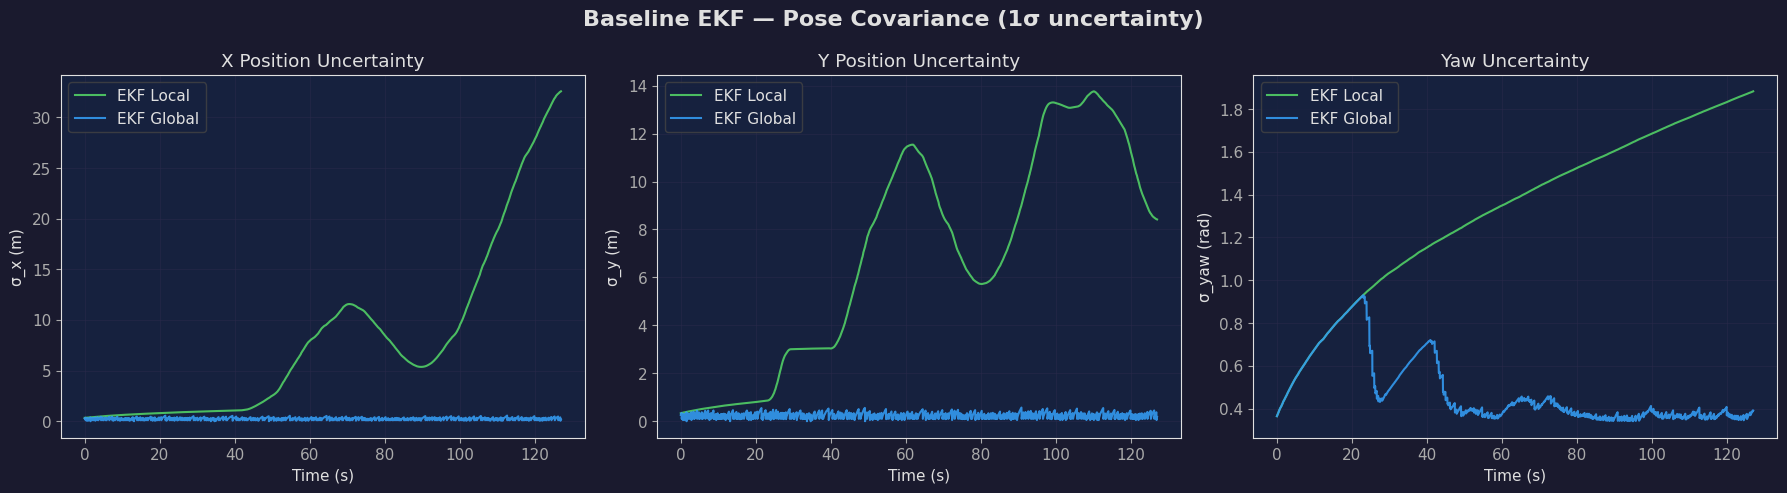

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Baseline EKF — Pose Covariance (1σ uncertainty)', fontsize=16, fontweight='bold')

for k, label, color in [('ekf_local', 'EKF Local', C['ekf_local']),
                          ('ekf_global', 'EKF Global', C['ekf_global'])]:
    if k not in dfs: continue
    df = dfs[k]
    t = npc(df, 't')
    sx = np.sqrt(np.abs(npc(df, 'cov_xx')))
    sy = np.sqrt(np.abs(npc(df, 'cov_yy')))
    syaw = np.sqrt(np.abs(npc(df, 'cov_yaw')))

    for ax, s, ylabel in zip(axes, [sx, sy, syaw],
                              ['σ_x (m)', 'σ_y (m)', 'σ_yaw (rad)']):
        m = mask_finite(t, s)
        ax.plot(t[m], s[m], color=color, lw=1.5, label=label, alpha=0.9)

for ax, ylabel, title in zip(axes,
    ['σ_x (m)', 'σ_y (m)', 'σ_yaw (rad)'],
    ['X Position Uncertainty', 'Y Position Uncertainty', 'Yaw Uncertainty']):
    ax.set_xlabel('Time (s)'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/08_covariance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Statistics Table

In [22]:
print('=' * 70)
print('BASELINE EKF — SUMMARY')
print('=' * 70)

if 'ekf_local' in dfs:
    d = dfs['ekf_local']
    dur = npc(d,'t')[-1] - npc(d,'t')[0]
    print(f'  Recording duration : {dur:.1f} s')

print('\nOdometry source noise (detrended vx std):')
for k, name in [('wheel','Wheel'), ('visual','Visual'), ('lidar','LiDAR')]:
    if k not in dfs: continue
    df = dfs[k]; vx = npc(df,'vx'); t = npc(df,'t'); m = mask_finite(t,vx)
    wl = min(51, max(5, (m.sum()//5)*2+1))
    if wl%2==0: wl+=1
    std = np.std(vx[m] - savgol_filter(vx[m], wl, 3))
    print(f'  {name:8}: vx σ = {std:.5f} m/s')

print('\nEKF drift:')
if 'ekf_local' in dfs and 'ekf_global' in dfs:
    tl = npc(dfs['ekf_local'],'t'); xl = npc(dfs['ekf_local'],'x'); yl = npc(dfs['ekf_local'],'y')
    tg = npc(dfs['ekf_global'],'t'); xg = npc(dfs['ekf_global'],'x'); yg = npc(dfs['ekf_global'],'y')
    ml = mask_finite(tl,xl,yl); mg = mask_finite(tg,xg,yg)
    t_c = np.linspace(max(tl[ml][0],tg[mg][0]), min(tl[ml][-1],tg[mg][-1]), 500)
    drift = np.sqrt((np.interp(t_c,tl[ml],xl[ml]-xl[ml][0]) - np.interp(t_c,tg[mg],xg[mg]-xg[mg][0]))**2 +
                    (np.interp(t_c,tl[ml],yl[ml]-yl[ml][0]) - np.interp(t_c,tg[mg],yg[mg]-yg[mg][0]))**2)
    print(f'  Final drift   : {drift[-1]:.4f} m')
    print(f'  Max drift     : {drift.max():.4f} m')
    print(f'  Drift rate    : {drift[-1]/(t_c[-1]-t_c[0])*60:.4f} m/min')

print('\nIMU raw noise:')
if 'imu' in dfs:
    for col, label in [('gz','Gyro Z'),('ax','Accel X'),('ay','Accel Y')]:
        d = npc(dfs['imu'], col)
        d = d[np.isfinite(d)]
        print(f'  {label:8}: σ = {d.std():.5f}')

BASELINE EKF — SUMMARY
  Recording duration : 127.0 s

Odometry source noise (detrended vx std):
  Wheel   : vx σ = 0.02123 m/s
  Visual  : vx σ = 0.30580 m/s
  LiDAR   : vx σ = 0.24249 m/s

EKF drift:
  Final drift   : 18.0701 m
  Max drift     : 18.4138 m
  Drift rate    : 8.5380 m/min

IMU raw noise:
  Gyro Z  : σ = 0.18404
  Accel X : σ = 0.29773
  Accel Y : σ = 0.30522
